In [1]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, OneHotEncoder

In [2]:
df=pd.read_csv(r'C:\xampp816\htdocs\personal-dev\py-ds\ML\regression\linear_regression\student_performance\Student_Performance.csv')
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [3]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [4]:
df.isna().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [5]:
df.dtypes

Hours Studied                         int64
Previous Scores                       int64
Extracurricular Activities           object
Sleep Hours                           int64
Sample Question Papers Practiced      int64
Performance Index                   float64
dtype: object

In [6]:
df['Extracurricular Activities'].value_counts()

Extracurricular Activities
No     4986
Yes    4887
Name: count, dtype: int64

In [7]:
label=[]
for i in df:
    if df[i].nunique()==2 and df[i].dtype=='object':
        label.append(i)
label

['Extracurricular Activities']

In [8]:
label_dict={}
for i in label:
      label_dict[i]=LabelEncoder()
      df[i]=label_dict[i].fit_transform(df[i])
label_dict

{'Extracurricular Activities': LabelEncoder()}

In [9]:
df.dtypes

Hours Studied                         int64
Previous Scores                       int64
Extracurricular Activities            int64
Sleep Hours                           int64
Sample Question Papers Practiced      int64
Performance Index                   float64
dtype: object

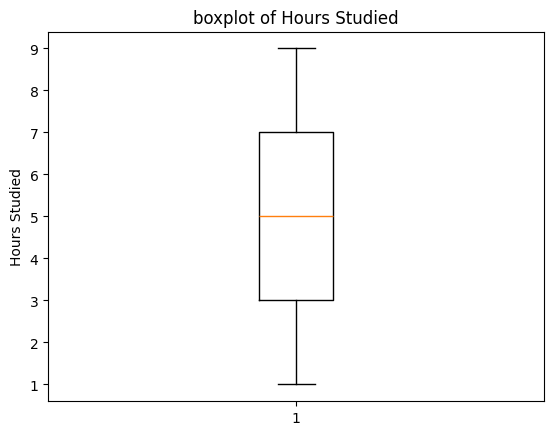

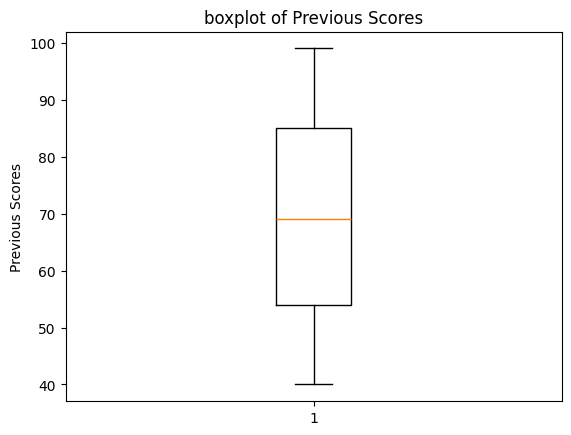

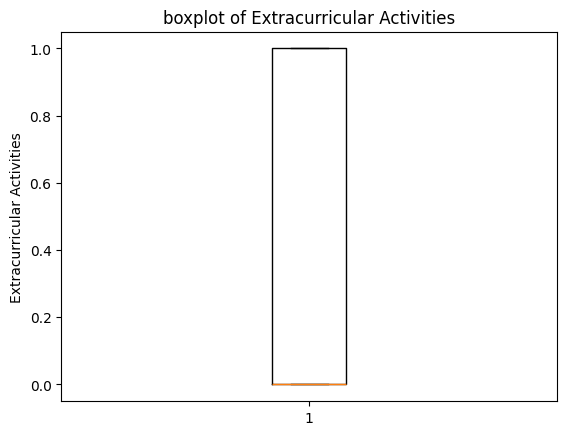

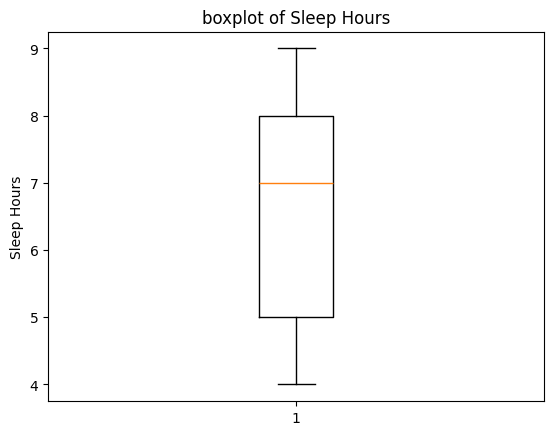

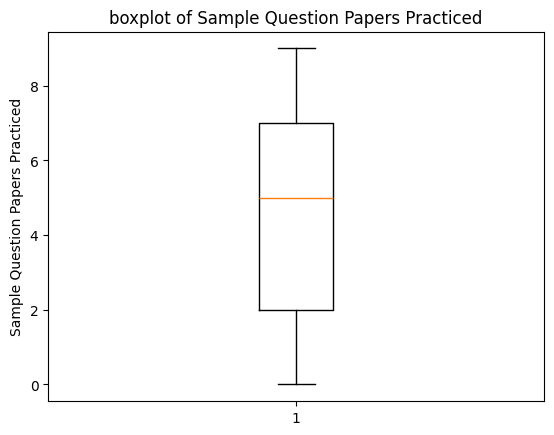

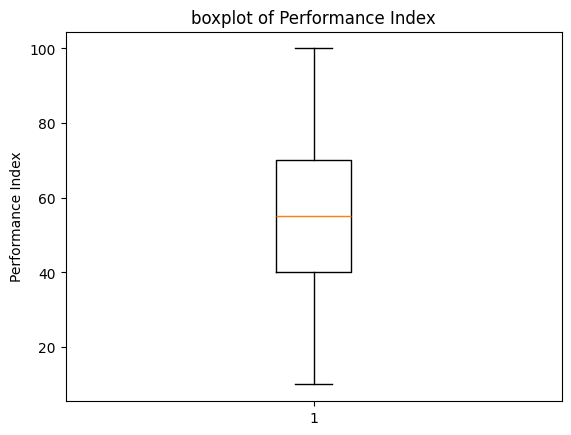

In [10]:
for i in df:
    if df[i].dtype=='int64' or df[i].dtype=='float':
        plt.boxplot(df[i])
        plt.title(f'boxplot of {i}')
        plt.ylabel(i)
        plt.show()

<Axes: >

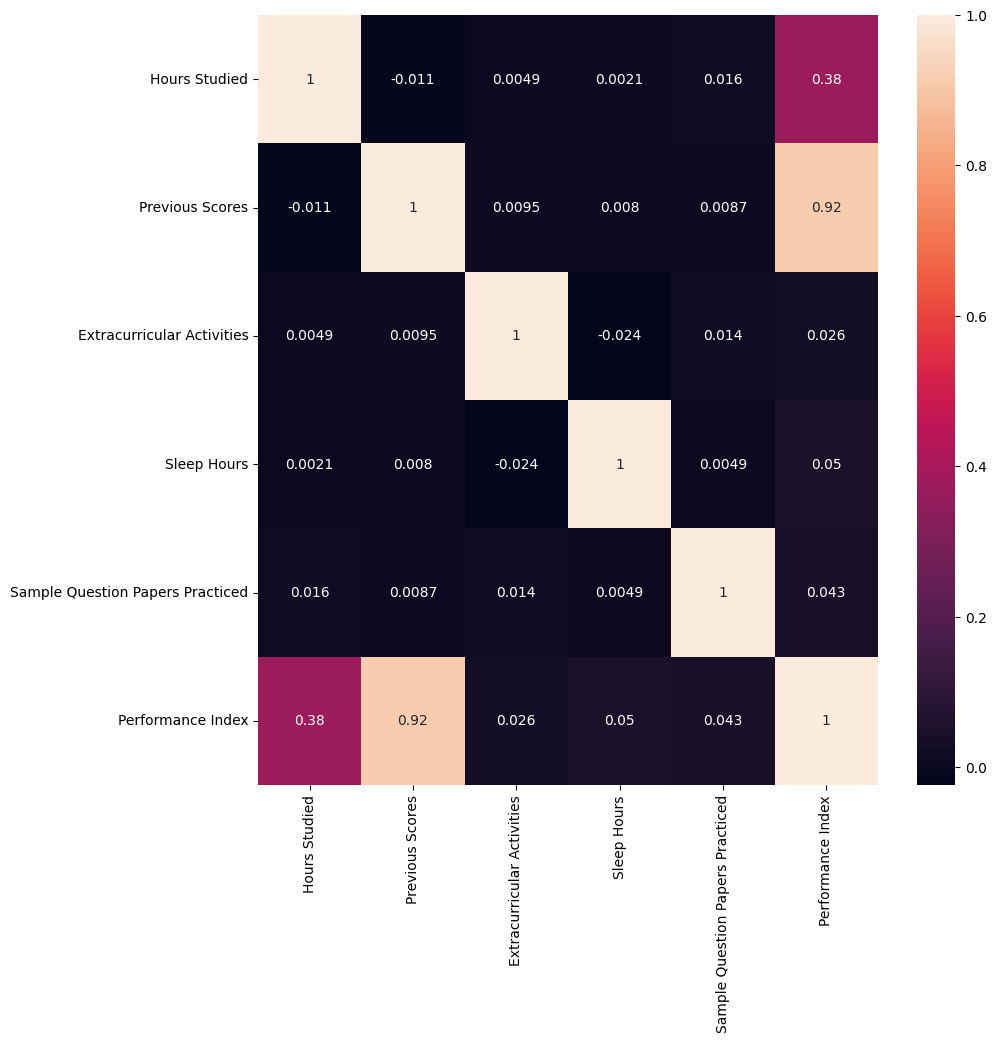

In [11]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [12]:
df.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

In [13]:
x=df.drop(columns='Performance Index')
y=df['Performance Index']

In [14]:
from sklearn.preprocessing import MinMaxScaler
minmax=MinMaxScaler()
x_scaled = minmax.fit_transform(x)

In [15]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.3, random_state=5)

In [16]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [17]:
y_pred = model.predict(x_test)

In [18]:
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
print("R squared Value", r2_score(y_test, y_pred))
print("Mean Absolute Error", mean_absolute_error(y_test, y_pred))
print("Root Mean Squared Value", root_mean_squared_error(y_test, y_pred))

R squared Value 0.9884308298055728
Mean Absolute Error 1.6274245782557988
Root Mean Squared Value 2.063328909874861


In [19]:
from sklearn.model_selection import cross_val_score
print('LinearRegression : ', cross_val_score(LinearRegression(),x_scaled, y, cv=10).mean()*100)

LinearRegression :  98.86462666911771


In [20]:
dict1 = {"model":model, 'scaler': minmax, 'label_encoder':label_dict['Extracurricular Activities']}
dict1

{'model': LinearRegression(),
 'scaler': MinMaxScaler(),
 'label_encoder': LabelEncoder()}

In [21]:
import pickle
with open("student_perf_model.pkl", 'wb') as obj1:
    pickle.dump(dict1, obj1)

In [22]:
import pickle
with open(r"C:\xampp816\htdocs\personal-dev\py-ds\ML\regression\linear_regression\student_performance\student_perf_model.pkl", 'rb') as obj2:
  var1=pickle.load(obj2)
var1

{'model': LinearRegression(),
 'scaler': MinMaxScaler(),
 'label_encoder': LabelEncoder()}

In [2]:
import streamlit